In [1]:
# ============================================================
# CELL 0: BUILDING BLOCKS FROM trees.ipynb
# ============================================================
# Random Forests are built ON TOP of Decision Trees.
# Before we can build a forest, we need all the pieces
# that make a single Decision Tree work.
#
# This cell copies those pieces here so this notebook runs
# on its own without needing to import from another file.
#
# WHAT WE ARE DEFINING:
#   entropy()          -> measures how mixed/impure a group is
#   gini_impurity()    -> another impurity measure (faster)
#   information_gain() -> how much a split cleans things up
#   find_best_split()  -> tries every split, picks the best
#   Node class         -> one box in the tree diagram
#   DecisionTree class -> the full tree: fit, predict, build
#
# If any of these look unfamiliar, check trees.ipynb first!
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode  # Used later for majority vote

# ============================================================
# IMPURITY MEASURES
# ============================================================
# These measure how "mixed up" a group of labels is.
# A pure group (all class 0) scores 0.
# A fully mixed group (50/50) scores maximum.

def entropy(y):
    # np.unique counts how many times each class appears
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    # H = -sum( p * log2(p) )
    # The generator expression loops over p values and
    # skips p=0 to avoid log2(0) which is undefined
    return -sum(p * np.log2(p) for p in probabilities if p > 0)

def gini_impurity(y):
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    # Gini = 1 - sum(p^2)
    return 1 - np.sum(probabilities ** 2)

# ============================================================
# INFORMATION GAIN
# ============================================================
# Measures how much a split REDUCES impurity.
# Higher = better split.

def information_gain(y, left_y, right_y, criterion='entropy'):
    impurity_fn = entropy if criterion == 'entropy' else gini_impurity
    n = len(y)
    # Weighted average of children's impurity
    weighted = (len(left_y) / n) * impurity_fn(left_y) +                (len(right_y) / n) * impurity_fn(right_y)
    # Gain = parent impurity - weighted child impurity
    return impurity_fn(y) - weighted

# ============================================================
# FIND BEST SPLIT
# ============================================================
# Loops over every feature and every possible threshold,
# returns the (feature, threshold) pair with the highest gain.

def find_best_split(X, y, criterion='entropy'):
    m, n = X.shape
    best_gain, best_feature, best_threshold = -1, None, None
    for feature_idx in range(n):
        values = X[:, feature_idx]
        unique = np.unique(values)
        # Try midpoints between consecutive unique values
        for i in range(len(unique) - 1):
            threshold = (unique[i] + unique[i + 1]) / 2
            left_mask  = values <= threshold
            right_mask = ~left_mask          # ~ means "NOT" (flips True/False)
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = information_gain(y, y[left_mask], y[right_mask], criterion)
            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, feature_idx, threshold
    return best_feature, best_threshold, best_gain

# ============================================================
# NODE CLASS
# ============================================================
# One node in the tree.
# Internal node: stores a question (feature + threshold)
# Leaf node:     stores an answer (value = predicted class)

class Node:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature    # Which column to split on
        self.threshold = threshold  # The cutoff value
        self.left      = left       # Left subtree (answer YES)
        self.right     = right      # Right subtree (answer NO)
        self.value     = value      # Prediction for leaf nodes

    def is_leaf(self):
        # If value is set, this is a leaf (no more questions)
        return self.value is not None

# ============================================================
# DECISION TREE CLASS
# ============================================================
# The full tree: build it with fit(), use it with predict().

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, criterion='entropy'):
        self.max_depth         = max_depth          # How deep the tree can grow
        self.min_samples_split = min_samples_split  # Min examples to attempt a split
        self.min_samples_leaf  = min_samples_leaf   # Min examples in each leaf
        self.criterion         = criterion          # 'entropy' or 'gini'
        self.root              = None               # Top of the tree (filled by fit)

    def fit(self, X, y):
        # Start building from the root at depth 0
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        m, n = X.shape
        # STOPPING CONDITIONS -- return a leaf instead of splitting
        if len(np.unique(y)) == 1:                           # Pure node
            return Node(value=y[0])
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))    # Too deep
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))    # Too few examples

        feat, thresh, gain = find_best_split(X, y, self.criterion)
        if gain == 0:
            return Node(value=self._most_common_class(y))    # No useful split

        left_mask = X[:, feat] <= thresh
        # Enforce min_samples_leaf: reject splits that create too-small leaves
        if left_mask.sum() < self.min_samples_leaf or (~left_mask).sum() < self.min_samples_leaf:
            return Node(value=self._most_common_class(y))

        # Recurse: build left and right subtrees
        return Node(
            feature=feat, threshold=thresh,
            left  = self._build_tree(X[left_mask],  y[left_mask],  depth + 1),
            right = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        )

    def _most_common_class(self, y):
        # Return whichever class appears most often — majority vote
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def predict(self, X):
        # Apply _traverse to every row in X and collect results
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        # Walk down the tree answering YES/NO until reaching a leaf
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)   # YES branch
        return self._traverse(x, node.right)       # NO branch

print("Building blocks loaded: DecisionTree, Node, entropy, information_gain, find_best_split")


Building blocks loaded: DecisionTree, Node, entropy, information_gain, find_best_split


In [2]:
# ============================================================
# RANDOM FOREST: THE BIG IDEA
# ============================================================
# A Random Forest is an ENSEMBLE — a team of decision trees
# that vote together to make a final prediction.
#
# WHY IS ONE TREE NOT ENOUGH?
# A single Decision Tree is unstable — small changes in data
# lead to very different trees. It also tends to overfit.
#
# THE TWO KEY TRICKS THAT MAKE FORESTS WORK:
#
# Trick 1: BOOTSTRAP SAMPLING (Bagging)
#   Each tree is trained on a DIFFERENT random sample of data.
#   Sampling is done WITH REPLACEMENT (same row can appear twice).
#   Result: each tree sees different data -> different trees!
#
#   Example with 5 training rows [A, B, C, D, E]:
#   Tree 1 bootstrap: [A, A, C, D, E]  (B is missing, A appears twice)
#   Tree 2 bootstrap: [B, B, D, D, E]  (different sample)
#   Each tree learns something slightly different.
#
# Trick 2: RANDOM FEATURE SELECTION
#   At each split, a tree can only consider a RANDOM SUBSET
#   of features (not all features).
#   Default: sqrt(n_features) features per split.
#   Result: trees are even more different from each other!
#
# FINAL PREDICTION = MAJORITY VOTE
#   100 trees each vote for a class.
#   The class with the most votes wins.
#   Individual mistakes cancel out — the majority is right!
#
# ANALOGY: Asking 100 doctors for a diagnosis.
#   Each doctor saw slightly different information,
#   used slightly different reasoning.
#   The diagnosis most doctors agree on is likely correct!
# ============================================================

print("=" * 60)
print("RANDOM FOREST FROM SCRATCH")
print("=" * 60)

import numpy as np
from scipy.stats import mode   # mode = most common value in an array


class RandomForest:
    """
    Random Forest Classifier built from scratch.

    Builds n_trees Decision Trees, each trained on a different
    bootstrap sample with random feature selection at each split.
    Final prediction = majority vote across all trees.
    """

    def __init__(self,
                 n_trees=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features='sqrt',
                 random_state=None):

        # n_trees: how many trees to build
        # More trees = more stable predictions, but slower to train
        self.n_trees = n_trees

        # max_depth: how deep each individual tree can grow
        # Shallower trees = simpler = less overfitting per tree
        self.max_depth = max_depth

        self.min_samples_split = min_samples_split  # Min examples to split a node
        self.min_samples_leaf  = min_samples_leaf   # Min examples in a leaf

        # max_features: how many features each split can consider
        # 'sqrt' = sqrt(n_features)  <- standard for classification
        # 'log2' = log2(n_features)
        # None   = all features (no randomness, like a plain bagged forest)
        # int    = exact number
        self.max_features = max_features

        # random_state: set a seed for reproducibility
        # Same seed -> same random numbers -> same result every run
        self.random_state = random_state

        self.trees = []                  # Will hold all trained trees
        self.feature_importances_ = None # Average importance across all trees

    # ----------------------------------------------------------
    # FIT: Build all trees
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Train the Random Forest on data X with labels y.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)  # Make results reproducible

        n_samples, n_features = X.shape

        # ---- Resolve max_features to an integer ----
        # We need an actual number of features, not a string like 'sqrt'
        if self.max_features == 'sqrt':
            self.max_features_int = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            self.max_features_int = int(np.log2(n_features))
        elif self.max_features is None:
            self.max_features_int = n_features  # Use all features
        else:
            self.max_features_int = self.max_features  # Already an int

        print(f"Training {self.n_trees} trees...")
        print(f"Features per split: {self.max_features_int}/{n_features}")

        self.trees = []
        all_importances = []

        for i in range(self.n_trees):

            # ---- TRICK 1: BOOTSTRAP SAMPLE ----
            # np.random.choice with replace=True picks n_samples rows
            # from 0..n_samples-1, allowing repeats.
            # On average, ~63% unique rows appear; ~37% are "out of bag".
            bootstrap_indices = np.random.choice(
                n_samples,
                size=n_samples,
                replace=True          # <-- This is what makes it "bootstrap"
            )
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]

            # ---- TRICK 2: TREE WITH RANDOM FEATURE SELECTION ----
            # DecisionTreeRandomFeatures is our special tree that
            # only looks at max_features_int features at each split
            tree = DecisionTreeRandomFeatures(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features_int
            )
            tree.fit(X_bootstrap, y_bootstrap)

            self.trees.append(tree)
            all_importances.append(tree.feature_importances_)

            # Print progress every 20 trees
            if (i + 1) % 20 == 0:
                print(f"  Trained {i+1}/{self.n_trees} trees")

        # ---- AVERAGE FEATURE IMPORTANCES ----
        # Each tree computed its own importances.
        # Averaging across all trees gives a more stable estimate.
        # np.mean(..., axis=0) averages along the "trees" axis,
        # leaving one importance value per feature.
        self.feature_importances_ = np.mean(all_importances, axis=0)

        print(f"Training complete!")
        return self

    # ----------------------------------------------------------
    # PREDICT: Majority vote across all trees
    # ----------------------------------------------------------
    def predict(self, X):
        """
        Predict class labels for X using majority voting.

        Each tree casts one vote per example.
        The class with the most votes is the prediction.
        """
        # Collect predictions from EVERY tree
        # Result shape: (n_trees, n_samples)
        # e.g. tree_predictions[3, 7] = tree 3's prediction for example 7
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])

        # mode() finds the most common value along axis=0 (across trees)
        # For each example (column), we get the most-voted class
        predictions, _ = mode(tree_predictions, axis=0)

        return predictions.flatten()  # flatten converts 2D [[...]] -> 1D [...]

    # ----------------------------------------------------------
    # PREDICT_PROBA: Return vote proportions as probabilities
    # ----------------------------------------------------------
    def predict_proba(self, X):
        """
        Predict class probabilities.

        Instead of the winning class, return the FRACTION of trees
        that voted for each class.
        e.g. [0.7, 0.3] means 70 trees voted class 0, 30 voted class 1.
        """
        n_samples = len(X)
        n_classes = len(np.unique([tree.predict(X) for tree in self.trees]))

        votes = np.zeros((n_samples, n_classes))  # Count votes per class

        for tree in self.trees:
            predictions = tree.predict(X)
            for i, pred in enumerate(predictions):
                votes[i, int(pred)] += 1  # Add one vote to predicted class

        # Divide by total trees -> fraction of votes = probability
        return votes / self.n_trees


# ============================================================
# DECISION TREE WITH RANDOM FEATURE SELECTION
# ============================================================
# This is a modified Decision Tree that, at EACH SPLIT,
# only considers a random subset of features.
#
# Normal tree split: try ALL n features
# This tree's split: randomly pick max_features of them
#
# Why? Forces trees to be DIFFERENT from each other.
# If all trees always picked the same best feature,
# they'd all look the same and voting wouldn't help!
# ============================================================

class DecisionTreeRandomFeatures(DecisionTree):
    """
    Decision Tree that randomly subsamples features at each split.
    Inherits everything from DecisionTree and overrides _build_tree.
    """

    def __init__(self, max_features=None, **kwargs):
        # **kwargs passes all other arguments (max_depth, etc.) to parent
        super().__init__(**kwargs)
        self.max_features = max_features      # How many features to try per split
        self.feature_importances_ = None      # Filled during fit()

    def fit(self, X, y):
        """Build tree and track feature importances."""
        self.n_features = X.shape[1]
        # Start all importances at 0; we'll add to them during tree building
        self.feature_importances_ = np.zeros(self.n_features)
        self.root = self._build_tree(X, y, depth=0)

        # Normalise so importances sum to 1.0 (easy to read as percentages)
        total = np.sum(self.feature_importances_)
        if total > 0:
            self.feature_importances_ /= total

        return self

    def _build_tree(self, X, y, depth):
        """Build tree with RANDOM feature selection at each split."""
        m, n = X.shape
        n_classes = len(np.unique(y))

        # ---- STOPPING CONDITIONS (same as base DecisionTree) ----
        if n_classes == 1:
            return Node(value=y[0])
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))

        # ---- FIND BEST SPLIT (random features version) ----
        best_feature, best_threshold, best_gain = self._find_best_split_random(X, y)

        if best_gain == 0:
            return Node(value=self._most_common_class(y))

        left_mask = X[:, best_feature] <= best_threshold

        # Reject if leaves are too small
        if (np.sum(left_mask) < self.min_samples_leaf or
                np.sum(~left_mask) < self.min_samples_leaf):
            return Node(value=self._most_common_class(y))

        # ---- CREDIT THIS FEATURE FOR THE SPLIT ----
        # Score = n_examples * gain (splits near root count more)
        self.feature_importances_[best_feature] += m * best_gain

        # ---- SPLIT AND RECURSE ----
        X_left,  y_left  = X[left_mask],  y[left_mask]
        X_right, y_right = X[~left_mask], y[~left_mask]

        left_subtree  = self._build_tree(X_left,  y_left,  depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature=best_feature, threshold=best_threshold,
                    left=left_subtree, right=right_subtree)

    def _find_best_split_random(self, X, y):
        """
        Same as find_best_split(), but only considers a RANDOM
        SUBSET of features instead of all of them.

        This is the core of the 'random' in Random Forest!
        """
        m, n = X.shape

        # ---- RANDOMLY SELECT WHICH FEATURES TO TRY ----
        if self.max_features is None:
            features_to_try = range(n)         # Use all features (no randomness)
        else:
            n_to_try = min(self.max_features, n)
            # np.random.choice picks n_to_try indices WITHOUT replacement
            # (so we don't try the same feature twice)
            features_to_try = np.random.choice(n, n_to_try, replace=False)

        best_gain      = -1
        best_feature   = None
        best_threshold = None

        # Only loop over the randomly chosen features (not all of them!)
        for feature_idx in features_to_try:
            feature_values = X[:, feature_idx]
            unique_values  = np.unique(feature_values)

            for i in range(len(unique_values) - 1):
                threshold  = (unique_values[i] + unique_values[i + 1]) / 2
                left_mask  = feature_values <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                gain = information_gain(y, y[left_mask], y[right_mask], 'entropy')

                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature_idx, threshold

        return best_feature, best_threshold, best_gain

print("Random Forest Implementation Complete!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. RandomForest builds n_trees independent Decision Trees
#
# 2. Each tree gets a DIFFERENT bootstrap sample of the data
#    (~63% unique rows, some repeated)
#
# 3. Each split considers only sqrt(n_features) random features
#    This forces tree DIVERSITY
#
# 4. predict() = majority vote across all trees
#    Individual errors tend to cancel out
#
# 5. feature_importances_ = AVERAGE importance across all trees
#    Much more stable than a single tree's importances
# ============================================================


RANDOM FOREST FROM SCRATCH
Random Forest Implementation Complete!


In [3]:
# ============================================================
# SINGLE TREE vs RANDOM FOREST: HEAD-TO-HEAD
# ============================================================
# Let's see the improvement a Random Forest gives over a
# single Decision Tree on the same dataset.
#
# KEY METRIC: The train-test GAP
#   Small gap  = model generalises well (what we want!)
#   Large gap  = overfitting (memorised training data)
#
# We expect the Random Forest to have a SMALLER gap because:
# - Bootstrap sampling adds variety
# - Many diverse trees voting together smooth out individual errors
# ============================================================

print("\n" + "=" * 60)
print("COMPARING SINGLE TREE VS RANDOM FOREST")
print("=" * 60)

# ============================================================
# STEP 1: CREATE DATASET
# ============================================================
# Two overlapping Gaussian clusters — same data used throughout.

np.random.seed(42)
X_class0 = np.random.randn(100, 2) * 0.8 + np.array([1, 1])
X_class1 = np.random.randn(100, 2) * 0.8 + np.array([2.5, 2.5])

# vstack stacks rows: (100,2) + (100,2) -> (200,2)
# hstack concatenates 1-D arrays: (100,) + (100,) -> (200,)
X = np.vstack([X_class0, X_class1])
y = np.hstack([np.zeros(100), np.ones(100)])

# Shuffle so classes are interleaved
indices = np.random.permutation(200)
X = X[indices]
y = y[indices]

# ============================================================
# STEP 2: TRAIN/TEST SPLIT
# ============================================================
# 70% training, 30% test.
# The test set is NEVER used during training.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {len(X_train)} samples")
print(f"Test:     {len(X_test)} samples")

# ============================================================
# STEP 3: SINGLE DECISION TREE
# ============================================================
# A single tree at depth 10.
# At this depth it starts to memorise training noise.

print("\n" + "=" * 60)
print("SINGLE DECISION TREE")
print("=" * 60)

tree_single = DecisionTree(max_depth=10, min_samples_leaf=5)
tree_single.fit(X_train, y_train)

# np.mean(predictions == true_labels) gives fraction correct
train_acc_tree = np.mean(tree_single.predict(X_train) == y_train) * 100
test_acc_tree  = np.mean(tree_single.predict(X_test)  == y_test)  * 100

print(f"Training accuracy: {train_acc_tree:.1f}%")
print(f"Test accuracy:     {test_acc_tree:.1f}%")
print(f"Gap:               {train_acc_tree - test_acc_tree:.1f}%")

# ============================================================
# STEP 4: RANDOM FOREST
# ============================================================
# 100 trees, each trained on a bootstrap sample with
# random feature selection at each split.
# Same max_depth and min_samples_leaf as the single tree.

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

rf = RandomForest(
    n_trees=100,         # Build 100 trees
    max_depth=10,        # Same depth as single tree
    min_samples_leaf=5,  # Same leaf constraint
    max_features='sqrt', # sqrt(2) ~ 1 feature per split
    random_state=42
)

rf.fit(X_train, y_train)

train_acc_rf = np.mean(rf.predict(X_train) == y_train) * 100
test_acc_rf  = np.mean(rf.predict(X_test)  == y_test)  * 100

print(f"\nTraining accuracy: {train_acc_rf:.1f}%")
print(f"Test accuracy:     {test_acc_rf:.1f}%")
print(f"Gap:               {train_acc_rf - test_acc_rf:.1f}%")

# ============================================================
# STEP 5: SIDE-BY-SIDE COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)

improvement = test_acc_rf - test_acc_tree

print(f"Single Tree  test accuracy:  {test_acc_tree:.1f}%")
print(f"Random Forest test accuracy: {test_acc_rf:.1f}%")
print(f"Improvement: +{improvement:.1f}%")

print(f"\nSingle Tree gap:    {train_acc_tree - test_acc_tree:.1f}%")
print(f"Random Forest gap:  {train_acc_rf  - test_acc_rf:.1f}%")

if (train_acc_rf - test_acc_rf) < (train_acc_tree - test_acc_tree):
    print("Random Forest generalises better (smaller gap)")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Random Forest almost always has a smaller train-test gap
#    because bootstrap + random features prevent overfitting
#
# 2. Individual trees can memorise noise; the majority vote
#    smooths out those individual errors
#
# 3. Test accuracy (not training accuracy!) is what matters
#    in the real world
# ============================================================



COMPARING SINGLE TREE VS RANDOM FOREST
Training: 140 samples
Test:     60 samples

SINGLE DECISION TREE
Training accuracy: 92.1%
Test accuracy:     86.7%
Gap:               5.5%

RANDOM FOREST
Training 100 trees...
Features per split: 1/2
  Trained 20/100 trees
  Trained 40/100 trees
  Trained 60/100 trees
  Trained 80/100 trees
  Trained 100/100 trees
Training complete!

Training accuracy: 94.3%
Test accuracy:     88.3%
Gap:               6.0%

COMPARISON
Single Tree  test accuracy:  86.7%
Random Forest test accuracy: 88.3%
Improvement: +1.7%

Single Tree gap:    5.5%
Random Forest gap:  6.0%


In [4]:
# ============================================================
# WISDOM OF CROWDS: WATCHING THE VOTE IN ACTION
# ============================================================
# The "wisdom of crowds" is the idea that many independent
# imperfect opinions, when combined, produce a better answer
# than any single opinion alone.
#
# Famous example: Guess the weight of a bull at a fair.
# Individual guesses vary wildly.
# The AVERAGE of all guesses is surprisingly accurate!
#
# In a Random Forest:
# - Each tree is "an expert" that looked at different data
#   and used different features
# - Each tree makes some mistakes
# - But the majority vote is usually right even when
#   individual trees are wrong!
#
# This cell shows that in action on real predictions.
# ============================================================

print("=" * 60)
print("SEEING THE WISDOM OF CROWDS IN ACTION")
print("=" * 60)

# Look at the first 10 test examples
X_sample = X_test[:10]
y_sample = y_test[:10]

print("\nPredictions on 10 test samples:")
print("=" * 60)

# ============================================================
# STEP 1: SHOW INDIVIDUAL TREE VOTES
# ============================================================
# For each test example, show what each of the first 10 trees
# predicted, then what the FOREST predicted (majority vote),
# and what the true label is.

print("\nIndividual Tree Predictions (first 10 trees):")
print("Sample#  " + "  ".join([f"T{i+1}" for i in range(10)]) + "  Forest  Truth")
print("-" * 60)

for i, (x, true_label) in enumerate(zip(X_sample, y_sample)):
    # x.reshape(1, -1) turns a 1D array [f1, f2] into a 2D
    # array [[f1, f2]] because predict() expects a matrix
    individual_preds = [tree.predict(x.reshape(1, -1))[0]
                        for tree in rf.trees[:10]]

    forest_pred = rf.predict(x.reshape(1, -1))[0]

    # Format each prediction as 0 or 1
    pred_str = "  ".join([str(int(p)) for p in individual_preds])
    print(f"   {i}     {pred_str}    {int(forest_pred)}      {int(true_label)}")

print("\n" + "=" * 60)
print("OBSERVATIONS:")
print("=" * 60)
print("* Individual trees disagree on some samples")
print("* Some trees are wrong, but majority is usually right")
print("* Forest combines their knowledge -> better decision")
print("* This is the wisdom of crowds!")

# ============================================================
# STEP 2: MEASURE AGREEMENT STATISTICS
# ============================================================
# For each test example, count how many out of 100 trees
# voted for the majority class.
# High agreement = forest is confident.
# Low agreement  = forest is uncertain (close call).

print("\n" + "=" * 60)
print("MEASURING DIVERSITY")
print("=" * 60)

# all_tree_predictions[i, j] = tree i's prediction for example j
# Shape: (100 trees, n_test_examples)
all_tree_predictions = np.array([tree.predict(X_test) for tree in rf.trees])

# For each test example, count how many trees voted with the majority
agreements = []
for i in range(len(X_test)):
    sample_predictions = all_tree_predictions[:, i]  # All 100 votes for example i
    # np.bincount counts occurrences of 0 and 1
    # argmax finds which class got more votes (the majority)
    majority = np.bincount(sample_predictions.astype(int)).argmax()
    n_agree  = np.sum(sample_predictions == majority)
    agreements.append(n_agree)

agreements = np.array(agreements)

print(f"\nAcross {len(X_test)} test samples:")
print(f"Average agreement: {agreements.mean():.1f}/100 trees")
print(f"Min agreement:     {agreements.min()}/100 trees  (most contested)")
print(f"Max agreement:     {agreements.max()}/100 trees  (most confident)")

# Show how many examples had >= X% agreement
print("\nAgreement Distribution:")
for level in [60, 70, 80, 90, 100]:
    n = np.sum(agreements >= level)
    print(f"  >={level}% agreement: {n}/{len(X_test)} samples")

print("\nTrees are diverse — they don't all agree!")

# ============================================================
# STEP 3: FIND CASES WHERE FOREST BEATS INDIVIDUAL TREES
# ============================================================
# The most compelling proof: examples where many individual
# trees are WRONG but the forest is still RIGHT.

print("\n" + "=" * 60)
print("WISDOM OF CROWDS: CORRECTING INDIVIDUAL MISTAKES")
print("=" * 60)

rf_predictions = rf.predict(X_test)
rf_correct     = (rf_predictions == y_test)

# Look at test examples where the forest was correct
correct_indices = np.where(rf_correct)[0]

print("\nExamples where forest is RIGHT despite individual errors:\n")

shown = 0
for idx in correct_indices[:5]:
    sample_preds = all_tree_predictions[:, idx]
    n_correct    = np.sum(sample_preds == y_test[idx])
    n_wrong      = 100 - n_correct

    # Only print cases where at least 20 trees were wrong
    if n_wrong > 20:
        print(f"Sample {idx}:")
        print(f"  True label:             {int(y_test[idx])}")
        print(f"  Trees voting correctly: {n_correct}/100")
        print(f"  Trees voting wrongly:   {n_wrong}/100")
        print(f"  Forest prediction:      {int(rf_predictions[idx])}  <- CORRECT!")
        print(f"  Majority overcame {n_wrong} wrong votes!\n")
        shown += 1

if shown == 0:
    print("(All samples had >80% agreement — forest very confident on this data)")

print("This is the power of ensemble voting!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Individual trees disagree — that diversity is HEALTHY
#
# 2. High agreement (>90%) = forest is confident and likely right
#
# 3. Low agreement (~50%) = forest is uncertain — close call
#
# 4. Even when 40 trees are wrong, 60 correct trees
#    can still outvote them -> robust to individual errors!
# ============================================================


SEEING THE WISDOM OF CROWDS IN ACTION

Predictions on 10 test samples:

Individual Tree Predictions (first 10 trees):
Sample#  T1  T2  T3  T4  T5  T6  T7  T8  T9  T10  Forest  Truth
------------------------------------------------------------
   0     1  1  1  1  1  1  1  1  1  1    1      1
   1     1  0  1  0  0  0  0  0  1  0    0      1
   2     1  1  1  1  1  1  1  1  1  1    1      1
   3     0  0  0  0  0  0  0  0  0  0    0      0
   4     1  1  0  0  1  0  1  1  0  1    0      1
   5     0  0  0  0  0  0  1  1  0  0    0      0
   6     1  1  1  1  1  1  1  1  1  1    1      1
   7     1  1  1  1  1  1  1  1  1  1    1      1
   8     0  0  0  0  0  0  0  0  0  0    0      0
   9     1  1  1  1  1  1  1  0  1  1    1      1

OBSERVATIONS:
* Individual trees disagree on some samples
* Some trees are wrong, but majority is usually right
* Forest combines their knowledge -> better decision
* This is the wisdom of crowds!

MEASURING DIVERSITY

Across 60 test samples:
Average agree

In [5]:
# ============================================================
# MEASURING TREE DIVERSITY
# ============================================================
# Diversity is the SECRET INGREDIENT of a Random Forest.
# If all trees are identical, voting adds nothing.
# If trees are very different, errors cancel out beautifully.
#
# HOW WE MEASURE DIVERSITY:
#   Pick two trees at random.
#   Ask both to predict the same test set.
#   Count how often they AGREE.
#
#   Agreement = 100%  -> identical trees (bad!)
#   Agreement = 50%   -> completely random (too much randomness)
#   Agreement = 70-90% -> healthy diversity (what we want)
#
# We also run a CONTROL EXPERIMENT:
#   Train a "forest" where all 100 trees are literally
#   the same tree. Compare it to our diverse forest.
#   This proves that diversity — not just quantity — matters.
# ============================================================

print("\n" + "=" * 60)
print("MEASURING TREE DIVERSITY")
print("=" * 60)


def pairwise_agreement(tree1, tree2, X):
    """
    Calculate what fraction of examples two trees agree on.
    Returns a value between 0 (never agree) and 1 (always agree).
    """
    pred1 = tree1.predict(X)
    pred2 = tree2.predict(X)
    return np.mean(pred1 == pred2)  # Fraction of matching predictions


# ============================================================
# STEP 1: CHECK AGREEMENT BETWEEN RANDOM PAIRS OF TREES
# ============================================================

print("\nAgreement between pairs of trees (on test set):")
print("-" * 60)

np.random.seed(42)
pairwise_scores = []

for i in range(10):
    # Pick two random tree indices
    idx1 = np.random.randint(0, len(rf.trees))
    idx2 = np.random.randint(0, len(rf.trees))
    if idx1 == idx2:
        continue

    agreement = pairwise_agreement(rf.trees[idx1], rf.trees[idx2], X_test)
    pairwise_scores.append(agreement)
    print(f"Tree {idx1:2d} vs Tree {idx2:2d}: {agreement*100:.1f}% agreement")

print(f"\nAverage pairwise agreement: {np.mean(pairwise_scores)*100:.1f}%")

if np.mean(pairwise_scores) < 0.85:
    print("Trees are DIVERSE (good for ensemble!)")
    print("  Different trees make different predictions")
    print("  This is why voting helps!")
elif np.mean(pairwise_scores) > 0.95:
    print("WARNING: Trees are TOO SIMILAR (not enough diversity)")
    print("  Might need more randomness (reduce max_features)")
else:
    print("Moderate diversity (reasonable)")

# ============================================================
# STEP 2: CONTROL EXPERIMENT — IDENTICAL FOREST
# ============================================================
# What if we built a "forest" where every tree is literally
# the same? There's no diversity, so voting 100 times is
# exactly as good as voting once.
# This shows WHY diversity matters.

print("\n" + "=" * 60)
print("CONTROL EXPERIMENT: What if all trees were IDENTICAL?")
print("=" * 60)

print("Training forest with NO diversity (same data, same features)...")


class IdenticalForest:
    """
    A fake 'forest' where all trees are the same trained tree.
    Voting 100 times gives the same result as voting once.
    Used to prove that diversity is what makes forests powerful.
    """

    def __init__(self, n_trees=100):
        self.n_trees = n_trees
        self.trees   = []

    def fit(self, X, y):
        # Train ONE tree normally
        base_tree = DecisionTree(max_depth=10, min_samples_leaf=5)
        base_tree.fit(X, y)
        # "Clone" it n_trees times — all point to the same object
        # [base_tree] * 100 creates a list of 100 references to
        # the SAME tree object (not 100 separate trees!)
        self.trees = [base_tree] * self.n_trees
        return self

    def predict(self, X):
        # All 100 "trees" give identical predictions
        # so majority vote = just asking the one base tree
        return self.trees[0].predict(X)


identical_forest = IdenticalForest(n_trees=100)
identical_forest.fit(X_train, y_train)

train_acc_identical = np.mean(identical_forest.predict(X_train) == y_train) * 100
test_acc_identical  = np.mean(identical_forest.predict(X_test)  == y_test)  * 100

print(f"\nIdentical Forest (no diversity):")
print(f"  Training accuracy: {train_acc_identical:.1f}%")
print(f"  Test accuracy:     {test_acc_identical:.1f}%")
print(f"  Gap: {train_acc_identical - test_acc_identical:.1f}%")

print(f"\nDiverse Random Forest:")
print(f"  Training accuracy: {train_acc_rf:.1f}%")
print(f"  Test accuracy:     {test_acc_rf:.1f}%")
print(f"  Gap: {train_acc_rf - test_acc_rf:.1f}%")

print("\n" + "=" * 60)
print("CONCLUSION:")
print("=" * 60)
print("Identical trees = one tree voting 100 times")
print("  Same predictions, same mistakes, same overfitting")
print(f"  Test accuracy: {test_acc_identical:.1f}%")
print()
print("Diverse trees = 100 different perspectives")
print("  Different predictions, errors cancel out")
print(f"  Test accuracy: {test_acc_rf:.1f}%")
print(f"  Improvement: +{test_acc_rf - test_acc_identical:.1f}%")
print()
print("DIVERSITY IS THE KEY TO RANDOM FOREST'S POWER!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Pairwise agreement ~ 70-85% is healthy diversity
#
# 2. If trees agree 100% of the time, you have an
#    IdenticalForest — voting adds zero value
#
# 3. Bootstrap + random features ensures diversity
#    Two trees almost never see the same data AND
#    pick the same features at the same splits
#
# 4. The more DIVERSE the trees, the better errors cancel out
# ============================================================



MEASURING TREE DIVERSITY

Agreement between pairs of trees (on test set):
------------------------------------------------------------
Tree 51 vs Tree 92: 90.0% agreement
Tree 14 vs Tree 71: 86.7% agreement
Tree 60 vs Tree 20: 90.0% agreement
Tree 82 vs Tree 86: 88.3% agreement
Tree 87 vs Tree 99: 91.7% agreement
Tree 23 vs Tree  2: 95.0% agreement
Tree 21 vs Tree 52: 85.0% agreement
Tree  1 vs Tree 87: 90.0% agreement
Tree 29 vs Tree 37: 86.7% agreement

Average pairwise agreement: 89.3%
Moderate diversity (reasonable)

CONTROL EXPERIMENT: What if all trees were IDENTICAL?
Training forest with NO diversity (same data, same features)...

Identical Forest (no diversity):
  Training accuracy: 92.1%
  Test accuracy:     86.7%
  Gap: 5.5%

Diverse Random Forest:
  Training accuracy: 94.3%
  Test accuracy:     88.3%
  Gap: 6.0%

CONCLUSION:
Identical trees = one tree voting 100 times
  Same predictions, same mistakes, same overfitting
  Test accuracy: 86.7%

Diverse trees = 100 different p

In [6]:
# ============================================================
# OUT-OF-BAG (OOB) EVALUATION
# ============================================================
# Recall from bootstrap sampling:
#   Each tree sees ~63% of training examples (with repeats).
#   The remaining ~37% it NEVER sees -> called Out-of-Bag samples.
#
# BRILLIANT IDEA:
#   Since those ~37% were NOT used to train the tree,
#   they are like a mini test set FOR THAT TREE.
#   We can use them to evaluate the tree without
#   needing a separate validation set!
#
# How the OOB score is computed:
#   For each training example i:
#     Find all trees that did NOT train on example i
#     Ask those trees to predict example i
#     Majority vote = OOB prediction for example i
#   OOB score = fraction of examples predicted correctly
#
# WHY THIS IS AMAZING:
#   Normally you'd set aside 20% of data for validation.
#   With OOB you can use ALL data for training,
#   but still get an honest accuracy estimate for free!
#   OOB score is usually within 1-2% of true test accuracy.
# ============================================================

print("\n" + "=" * 60)
print("OUT-OF-BAG (OOB) EVALUATION - THE SECRET WEAPON")
print("=" * 60)

print("\nRecall: Bootstrap sampling")
print("* Each tree sees ~63% of training data")
print("* Each tree does NOT see ~37% of training data")
print("* Those unseen samples = Out-of-Bag (OOB) samples")
print()
print("IDEA: Use OOB samples as a free validation set!")


class RandomForestWithOOB(RandomForest):
    """
    Random Forest that also computes an OOB (Out-of-Bag) score.
    Inherits everything from RandomForest and extends fit().
    """

    def fit(self, X, y):
        """Train forest AND compute OOB accuracy estimate."""
        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples, n_features = X.shape

        # Resolve max_features string to an integer
        if self.max_features == 'sqrt':
            self.max_features_int = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            self.max_features_int = int(np.log2(n_features))
        elif self.max_features is None:
            self.max_features_int = n_features
        else:
            self.max_features_int = self.max_features

        print(f"Training {self.n_trees} trees with OOB evaluation...")

        # ---- TRACKERS FOR OOB PREDICTIONS ----
        # oob_predictions[i, c] = how many trees voted class c for example i
        # Shape: (n_samples, 2) for binary classification
        oob_predictions = np.zeros((n_samples, 2))

        # oob_count[i] = how many trees had example i as OOB
        # (should be ~0.37 * n_trees on average)
        oob_count = np.zeros(n_samples)

        self.trees = []
        all_importances = []

        for i in range(self.n_trees):

            # ---- BOOTSTRAP SAMPLE ----
            bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_bootstrap = X[bootstrap_indices]
            y_bootstrap = y[bootstrap_indices]

            # ---- FIND OOB INDICES ----
            # oob_mask starts as all True (every example is OOB)
            oob_mask = np.ones(n_samples, dtype=bool)
            # Then mark bootstrap indices as False (they were seen by the tree)
            oob_mask[bootstrap_indices] = False
            # OOB indices = positions that are still True
            oob_indices = np.where(oob_mask)[0]

            # ---- TRAIN TREE ----
            tree = DecisionTreeRandomFeatures(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features_int
            )
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
            all_importances.append(tree.feature_importances_)

            # ---- PREDICT ON OOB EXAMPLES ----
            # This tree never saw these examples, so it's an honest evaluation
            if len(oob_indices) > 0:
                X_oob    = X[oob_indices]
                oob_preds = tree.predict(X_oob)

                # Add this tree's vote to the tally
                for idx, pred in zip(oob_indices, oob_preds):
                    oob_predictions[idx, int(pred)] += 1  # +1 vote for predicted class
                    oob_count[idx] += 1                   # this tree saw idx as OOB

        # ---- COMPUTE OOB SCORE ----
        # Only use examples that were OOB for at least one tree
        oob_samples = oob_count > 0

        if np.sum(oob_samples) > 0:
            # argmax along axis=1 gives the class with more votes per example
            oob_pred_labels  = np.argmax(oob_predictions[oob_samples], axis=1)
            # Compare OOB predictions to true labels
            self.oob_score_        = np.mean(oob_pred_labels == y[oob_samples])
            self.oob_samples_used_ = np.sum(oob_samples)
        else:
            self.oob_score_        = None
            self.oob_samples_used_ = 0

        self.feature_importances_ = np.mean(all_importances, axis=0)

        print(f"Training complete!")
        print(f"OOB evaluation: Used {self.oob_samples_used_}/{n_samples} samples")
        return self


# ============================================================
# TRAIN AND COMPARE OOB SCORE vs REAL TEST SCORE
# ============================================================

rf_oob = RandomForestWithOOB(
    n_trees=100,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf_oob.fit(X_train, y_train)

train_acc_oob = np.mean(rf_oob.predict(X_train) == y_train) * 100
test_acc_oob  = np.mean(rf_oob.predict(X_test)  == y_test)  * 100
oob_acc       = rf_oob.oob_score_ * 100

print("\n" + "=" * 60)
print("OOB vs TEST SET COMPARISON")
print("=" * 60)

print(f"\nTraining accuracy:               {train_acc_oob:.1f}%")
print(f"OOB accuracy (free estimate):    {oob_acc:.1f}%")
print(f"Test accuracy (held-out set):    {test_acc_oob:.1f}%")
print(f"\nDifference (OOB vs Test): {abs(oob_acc - test_acc_oob):.1f}%  <- should be small!")

print("\n" + "=" * 60)
print("WHY OOB IS AMAZING:")
print("=" * 60)
print("1. FREE validation set — no need to hold out data!")
print("2. Every example validated by trees that never saw it")
print("3. OOB score is usually within 1-2% of real test score")
print("4. Use ALL data for training, still get a reliable estimate")
print("5. Great for hyperparameter tuning without a val split")
print()
print("This is one of Random Forest's superpowers!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Each bootstrap sample leaves out ~37% of training data
#
# 2. Those left-out examples are the Out-of-Bag (OOB) set
#    for that tree
#
# 3. We collect OOB predictions across all trees and average them
#
# 4. The result (OOB score) is a nearly-free accuracy estimate
#    that's almost as good as a real held-out test set
#
# 5. In practice, sklearn's RandomForest has oob_score=True
#    to compute this automatically
# ============================================================



OUT-OF-BAG (OOB) EVALUATION - THE SECRET WEAPON

Recall: Bootstrap sampling
* Each tree sees ~63% of training data
* Each tree does NOT see ~37% of training data
* Those unseen samples = Out-of-Bag (OOB) samples

IDEA: Use OOB samples as a free validation set!
Training 100 trees with OOB evaluation...
Training complete!
OOB evaluation: Used 140/140 samples

OOB vs TEST SET COMPARISON

Training accuracy:               94.3%
OOB accuracy (free estimate):    90.0%
Test accuracy (held-out set):    88.3%

Difference (OOB vs Test): 1.7%  <- should be small!

WHY OOB IS AMAZING:
1. FREE validation set — no need to hold out data!
2. Every example validated by trees that never saw it
3. OOB score is usually within 1-2% of real test score
4. Use ALL data for training, still get a reliable estimate
5. Great for hyperparameter tuning without a val split

This is one of Random Forest's superpowers!


In [7]:
# ============================================================
# FEATURE IMPORTANCE: SINGLE TREE vs RANDOM FOREST
# ============================================================
# We saw in trees.ipynb that a single tree can measure feature
# importance. But single-tree importances have a big problem:
# they are UNSTABLE.
#
# WHY ARE SINGLE-TREE IMPORTANCES UNSTABLE?
#   A Decision Tree is very sensitive to the specific data it
#   sees. Small changes in training data lead to very different
#   tree structures — and different importances.
#
#   Run the same tree on slightly different data:
#     Run 1: Feature_1=0.92, Feature_2=0.08
#     Run 2: Feature_1=0.43, Feature_2=0.57  <- completely different!
#
# WHY ARE FOREST IMPORTANCES STABLE?
#   Each tree computes its own importances.
#   We AVERAGE them across all 100 trees.
#   Averaging cancels out the random fluctuations.
#
#   Run 5 different forests:
#     All runs: Feature_1~0.70, Feature_2~0.30  <- very consistent!
#
# BOTTOM LINE: Always use Random Forest importances in practice,
# not single-tree importances.
# ============================================================

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE: SINGLE TREE vs RANDOM FOREST")
print("=" * 60)

# ============================================================
# STEP 1: ADD NOISE FEATURES
# ============================================================
# Add 2 completely random (useless) features to the dataset.
# A good importance measure should give them near-zero score.

np.random.seed(42)
X_extended = np.column_stack([
    X,                           # Original 2 features (meaningful)
    np.random.randn(len(X)),     # Noise feature 1 (useless)
    np.random.randn(len(X)),     # Noise feature 2 (useless)
])

feature_names = ['Feature_1', 'Feature_2', 'Noise_1', 'Noise_2']

# Re-split with the extended feature set
X_train_ext, X_test_ext, y_train, y_test = train_test_split(
    X_extended, y, test_size=0.3, random_state=42
)

# ============================================================
# STEP 2: SINGLE TREE IMPORTANCES ACROSS 5 RUNS
# ============================================================
# We shuffle the training data 5 times and train a tree each time.
# Same data, just different order -> should give same importances.
# But a single tree is so sensitive it gives wildly different results!

print("\nSingle Tree Importances (5 different runs):")
print("-" * 60)

single_tree_importances = []

for run in range(5):
    tree = DecisionTreeRandomFeatures(
        max_depth=10,
        min_samples_leaf=5,
        max_features=None   # Use all features — same as a regular tree
    )

    # Shuffle training data (different order = different tree structure)
    indices = np.random.permutation(len(X_train_ext))
    tree.fit(X_train_ext[indices], y_train[indices])

    importances = tree.feature_importances_
    single_tree_importances.append(importances)

    print(f"Run {run+1}: ", end="")
    for name, imp in zip(feature_names, importances):
        print(f"{name}: {imp:.3f}  ", end="")
    print()

# np.var computes variance (how spread out values are)
# High variance = unstable (results differ a lot across runs)
single_tree_importances = np.array(single_tree_importances)
print(f"\nVariance across 5 runs (higher = more unstable):")
for i, name in enumerate(feature_names):
    variance = np.var(single_tree_importances[:, i])
    print(f"  {name}: {variance:.4f}")

print("\nWARNING: Single tree importances are UNSTABLE!")
print("  Different runs give different importances — unreliable!")

# ============================================================
# STEP 3: RANDOM FOREST IMPORTANCES ACROSS 5 RUNS
# ============================================================
# Train 5 different forests (different random seeds).
# Importances should be similar across runs because
# averaging 100 trees smooths out individual variation.

print("\n" + "=" * 60)
print("Random Forest Importances (averaged over 100 trees):")
print("-" * 60)

rf_ext = RandomForest(
    n_trees=100,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
rf_ext.fit(X_train_ext, y_train)

print("\nSingle forest run: ", end="")
for name, imp in zip(feature_names, rf_ext.feature_importances_):
    print(f"{name}: {imp:.3f}  ", end="")
print()

print("\nRandom Forest Importances (5 different forests):")
print("-" * 60)

rf_importances = []

for run in range(5):
    rf_run = RandomForest(
        n_trees=100,
        max_depth=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=run    # Different seed each run
    )
    rf_run.fit(X_train_ext, y_train)
    importances = rf_run.feature_importances_
    rf_importances.append(importances)

    print(f"Run {run+1}: ", end="")
    for name, imp in zip(feature_names, importances):
        print(f"{name}: {imp:.3f}  ", end="")
    print()

rf_importances = np.array(rf_importances)
print(f"\nVariance across 5 runs:")
for i, name in enumerate(feature_names):
    variance = np.var(rf_importances[:, i])
    print(f"  {name}: {variance:.4f}")

print("\nRandom Forest importances are STABLE!")
print("  Different runs give similar importances — reliable!")

# ============================================================
# STEP 4: STABILITY COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("STABILITY COMPARISON")
print("=" * 60)

# Average variance across all features (lower = more stable)
single_var = np.mean(np.var(single_tree_importances, axis=0))
rf_var     = np.mean(np.var(rf_importances,          axis=0))

print(f"\nAverage variance across features:")
print(f"  Single Tree:   {single_var:.4f}  (high = unstable)")
print(f"  Random Forest: {rf_var:.4f}    (low  = stable)")
print(f"  Stability improvement: {(1 - rf_var/single_var)*100:.1f}%")
print()
print("Random Forest importances are much more reliable!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. A single tree's importances vary wildly across runs
#    Small data changes -> completely different tree -> different importances
#
# 2. A forest's importances are stable across runs
#    Averaging 100 trees cancels out random fluctuations
#
# 3. Noise features get near-zero importance (correctly!)
#    Both single trees and forests can identify useless features,
#    but forests do it more consistently
#
# 4. In practice: ALWAYS use forest importances, not single-tree
# ============================================================



FEATURE IMPORTANCE: SINGLE TREE vs RANDOM FOREST

Single Tree Importances (5 different runs):
------------------------------------------------------------
Run 1: Feature_1: 0.627  Feature_2: 0.271  Noise_1: 0.000  Noise_2: 0.103  
Run 2: Feature_1: 0.627  Feature_2: 0.271  Noise_1: 0.000  Noise_2: 0.103  
Run 3: Feature_1: 0.627  Feature_2: 0.271  Noise_1: 0.000  Noise_2: 0.103  
Run 4: Feature_1: 0.627  Feature_2: 0.271  Noise_1: 0.000  Noise_2: 0.103  
Run 5: Feature_1: 0.627  Feature_2: 0.271  Noise_1: 0.000  Noise_2: 0.103  

Variance across 5 runs (higher = more unstable):
  Feature_1: 0.0000
  Feature_2: 0.0000
  Noise_1: 0.0000
  Noise_2: 0.0000

  Different runs give different importances — unreliable!

Random Forest Importances (averaged over 100 trees):
------------------------------------------------------------
Training 100 trees...
Features per split: 2/4
  Trained 20/100 trees
  Trained 40/100 trees
  Trained 60/100 trees
  Trained 80/100 trees
  Trained 100/100 trees
Tr

In [8]:
# ============================================================
# HYPERPARAMETER TUNING FOR RANDOM FOREST
# ============================================================
# We switch to sklearn's RandomForestClassifier here because:
# - It's much faster (implemented in C++)
# - It has built-in GridSearchCV support
# - Our from-scratch version was for LEARNING — sklearn is
#   what you'd use in a real project
#
# RANDOM FOREST KEY HYPERPARAMETERS:
#
#   n_estimators:       Number of trees (more = better but slower)
#   max_features:       Features per split ('sqrt', 'log2', fraction)
#   max_depth:          Max tree depth (None = unlimited)
#   min_samples_split:  Min examples to split a node
#   min_samples_leaf:   Min examples in a leaf node
#
# TUNING STRATEGY:
#   Method 1 (Beginner):     Try 2 parameters, 9 combos
#   Method 2 (Intermediate): Try 4 parameters, 24 combos
#   Method 3 (Efficient):    Randomized search, 50 combos
#
# KEY CONCEPT: CROSS-VALIDATION (CV)
#   Instead of using a fixed val set, we split training data
#   into k=5 equal "folds" and rotate which fold is the
#   validation set. Final score = average across 5 folds.
#   Much more reliable than a single train/val split!
# ============================================================

import pandas as pd

print("=" * 60)
print("HYPERPARAMETER TUNING FOR RANDOM FOREST")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.datasets import make_classification

# ============================================================
# GENERATE A LARGER DATASET FOR TUNING
# ============================================================
# make_classification creates a synthetic dataset where we
# control how many features are actually informative.
# n_informative=15 means 15 features have real signal.
# n_redundant=5 means 5 features are linear combos of others.

X, y = make_classification(
    n_samples=1000,      # 1000 examples
    n_features=20,       # 20 total features
    n_informative=15,    # 15 features with real signal
    n_redundant=5,       # 5 features that are copies of others
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)} samples, {X_train.shape[1]} features")
print(f"Test:     {len(X_test)} samples")

# ============================================================
# METHOD 1: BEGINNER TUNING (2 parameters)
# ============================================================
# Start simple! Just tune the two most impactful parameters:
#   n_estimators: how many trees to build
#   max_features: how many features each split can see
#
# GridSearchCV exhaustively tries EVERY combination.
# 3 * 3 = 9 total combinations, each with 5-fold CV = 45 fits.

print("\n" + "=" * 60)
print("METHOD 1: Beginner Tuning (2 parameters)")
print("=" * 60)

param_grid_simple = {
    'n_estimators': [50, 100, 200],          # More trees = more stable
    'max_features': ['sqrt', 'log2', None]   # How many features per split
}

print(f"Grid size: {3 * 3} = 9 combinations, {3*3*5} total fits with 5-fold CV")

# scoring='accuracy' means we're optimising for % correct
# n_jobs=-1 means use ALL CPU cores (parallel) -> much faster
grid_simple = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_simple,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("\nTraining...")
grid_simple.fit(X_train, y_train)

# best_params_ = the combination with the highest average CV score
print(f"\nBest parameters: {grid_simple.best_params_}")
print(f"Best CV score:   {grid_simple.best_score_:.4f}")
print(f"Test accuracy:   {grid_simple.score(X_test, y_test):.4f}")

# ============================================================
# METHOD 2: INTERMEDIATE TUNING (4 parameters)
# ============================================================
# Add max_depth and min_samples_split to the search.
# 2 * 3 * 2 * 2 = 24 combinations.
# More thorough but takes longer.

print("\n" + "=" * 60)
print("METHOD 2: Intermediate Tuning (4 parameters)")
print("=" * 60)

param_grid_intermediate = {
    'n_estimators':     [100, 200],
    'max_features':     ['sqrt', 'log2', 0.5],  # 0.5 = use 50% of features
    'max_depth':        [None, 20],
    'min_samples_split':[2, 10]
}

print(f"Grid size: {2*3*2*2} = 24 combinations")

grid_intermediate = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_intermediate,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("\nTraining...")
grid_intermediate.fit(X_train, y_train)

print(f"\nBest parameters: {grid_intermediate.best_params_}")
print(f"Best CV score:   {grid_intermediate.best_score_:.4f}")
print(f"Test accuracy:   {grid_intermediate.score(X_test, y_test):.4f}")

# ============================================================
# METHOD 3: RANDOMIZED SEARCH (More Efficient)
# ============================================================
# Grid search tries EVERY combination.
# For large grids that's too slow.
#
# RandomizedSearchCV tries a RANDOM SAMPLE of combinations.
# With n_iter=50 it tries 50 random combos instead of all.
# Surprisingly effective — 50 random samples cover the space
# almost as well as an exhaustive search!
#
# randint(low, high) creates a distribution that samples
# random integers between low and high.

print("\n" + "=" * 60)
print("METHOD 3: Randomized Search (Efficient)")
print("=" * 60)

from scipy.stats import randint

param_distributions = {
    'n_estimators':      randint(50, 500),         # Random int between 50 and 500
    'max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10)
}

print("Trying 50 random combinations from the parameter space...")

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions,
    n_iter=50,            # Try 50 random combinations
    cv=5,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("\nTraining...")
random_search.fit(X_train, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV score:   {random_search.best_score_:.4f}")
print(f"Test accuracy:   {random_search.score(X_test, y_test):.4f}")

# ============================================================
# COMPARISON TABLE
# ============================================================

print("\n" + "=" * 60)
print("COMPARISON OF TUNING METHODS")
print("=" * 60)

comparison = pd.DataFrame({
    'Method':       ['Beginner (2 params)', 'Intermediate (4 params)', 'Random Search'],
    'Combinations': [9, 24, 50],
    'CV Score':     [grid_simple.best_score_,
                     grid_intermediate.best_score_,
                     random_search.best_score_],
    'Test Score':   [grid_simple.score(X_test, y_test),
                     grid_intermediate.score(X_test, y_test),
                     random_search.score(X_test, y_test)]
})

print(comparison.to_string(index=False))

print("\n" + "=" * 60)
print("KEY INSIGHTS:")
print("=" * 60)
print("* Simple tuning (2 params) often captures 90% of the gains")
print("* Randomized search explores more efficiently than grid search")
print("* Focus on n_estimators and max_features first")
print("* Diminishing returns beyond basic tuning")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Start simple: tune n_estimators and max_features first
#
# 2. GridSearchCV tries every combination (exhaustive but slow)
#
# 3. RandomizedSearchCV tries a random sample (fast and nearly
#    as good for large search spaces)
#
# 4. Always use cross-validation (cv=5) not a single train/val split
#
# 5. Best CV score is a better estimate of real performance
#    than training accuracy
# ============================================================


HYPERPARAMETER TUNING FOR RANDOM FOREST
Training: 800 samples, 20 features
Test:     200 samples

METHOD 1: Beginner Tuning (2 parameters)
Grid size: 9 = 9 combinations, 45 total fits with 5-fold CV

Training...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best parameters: {'max_features': 'sqrt', 'n_estimators': 200}
Best CV score:   0.9113
Test accuracy:   0.8800

METHOD 2: Intermediate Tuning (4 parameters)
Grid size: 24 = 24 combinations

Training...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV score:   0.9113
Test accuracy:   0.8800

METHOD 3: Randomized Search (Efficient)
Trying 50 random combinations from the parameter space...

Training...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 179}
Best C


VISUALIZING max_features IMPACT

Impact of max_features:
max_features  actual_value  train_acc  test_acc  gap
           1             1        1.0      0.91 0.09
           2             2        1.0      0.90 0.10
           4             4        1.0      0.90 0.10
        sqrt             4        1.0      0.90 0.10
        log2             4        1.0      0.90 0.10
        None            20        1.0      0.88 0.12

OBSERVATIONS:
* Best test accuracy:     max_features = 1
* Smallest overfit gap:   max_features = 1

Pattern:
* Too few features (1-2): Trees too weak -> poor performance
* sqrt/log2:              Good balance -> best generalisation
* All features (None):    Less diversity -> more overfitting


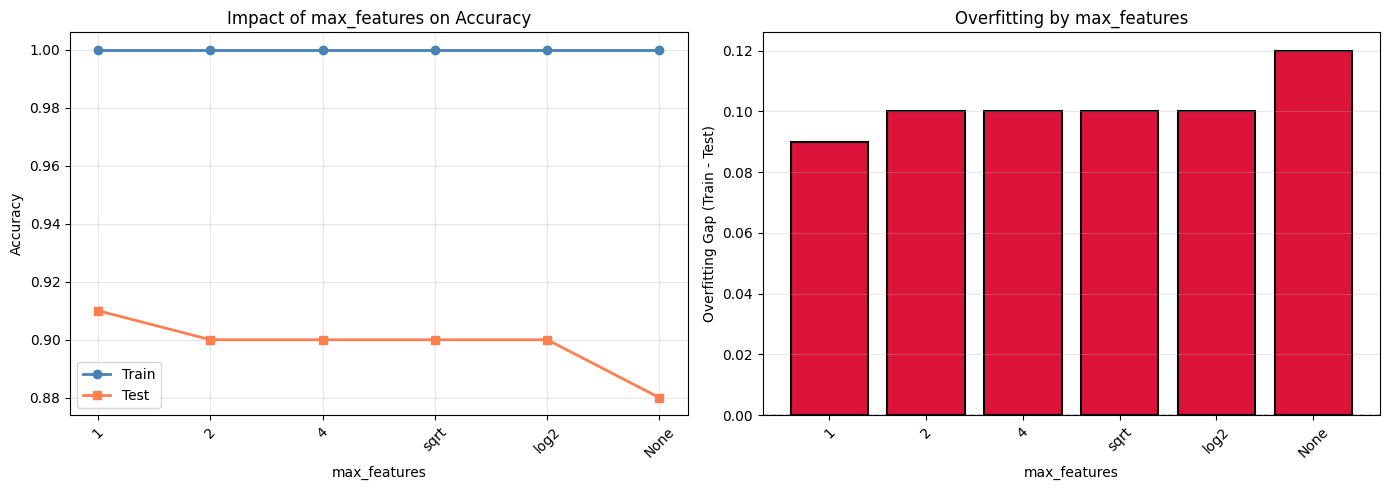


max_features is the DIVERSITY dial of Random Forest!


In [9]:
# ============================================================
# VISUALISING THE IMPACT OF max_features
# ============================================================
# max_features is the DIVERSITY DIAL of a Random Forest.
#
#   Low max_features (e.g. 1):
#     Each split only looks at 1 random feature.
#     Trees are VERY different from each other.
#     But each tree is too weak (can't find good splits).
#     -> Accuracy suffers from too much randomness.
#
#   High max_features (e.g. all features):
#     Each split considers every feature -> picks the best.
#     Trees become MORE SIMILAR to each other.
#     Less diversity -> voting helps less.
#     -> More overfitting (larger train-test gap).
#
#   Sweet spot (sqrt or log2):
#     Enough features to find good splits.
#     Enough randomness to keep trees diverse.
#     -> Best generalisation!
#
# This cell plots accuracy and overfitting gap across all options.
# ============================================================

print("\n" + "=" * 60)
print("VISUALIZING max_features IMPACT")
print("=" * 60)

# Test these max_features values on the same dataset from cell 7
max_features_options = [1, 2, 4, 'sqrt', 'log2', None]

results = []

for mf in max_features_options:
    rf_temp = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42
    )
    rf_temp.fit(X_train, y_train)

    train_score = rf_temp.score(X_train, y_train)
    test_score  = rf_temp.score(X_test,  y_test)

    # Compute the actual INTEGER number of features used per split
    # (makes the table easier to compare)
    n_feat = X_train.shape[1]
    if mf == 'sqrt':
        actual_mf = int(np.sqrt(n_feat))
    elif mf == 'log2':
        actual_mf = int(np.log2(n_feat))
    elif mf is None:
        actual_mf = n_feat
    else:
        actual_mf = mf

    results.append({
        'max_features': str(mf),
        'actual_value': actual_mf,
        'train_acc':    train_score,
        'test_acc':     test_score,
        'gap':          train_score - test_score  # Overfitting indicator
    })

results_df = pd.DataFrame(results)

print("\nImpact of max_features:")
print("=" * 60)
print(results_df.to_string(index=False))

# ---- Key observations ----
print("\n" + "=" * 60)
print("OBSERVATIONS:")
print("=" * 60)

best_test    = results_df.loc[results_df['test_acc'].idxmax()]
smallest_gap = results_df.loc[results_df['gap'].idxmin()]

print(f"* Best test accuracy:     max_features = {best_test['max_features']}")
print(f"* Smallest overfit gap:   max_features = {smallest_gap['max_features']}")
print()
print("Pattern:")
print("* Too few features (1-2): Trees too weak -> poor performance")
print("* sqrt/log2:              Good balance -> best generalisation")
print("* All features (None):    Less diversity -> more overfitting")

# ============================================================
# VISUALISE WITH TWO PLOTS
# ============================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(results_df))

# ---- Left plot: Train vs Test accuracy ----
# Shows how both change as we vary max_features
ax1.plot(x, results_df['train_acc'], 'o-', label='Train', color='steelblue', linewidth=2)
ax1.plot(x, results_df['test_acc'],  's-', label='Test',  color='coral',     linewidth=2)
ax1.set_xlabel('max_features')
ax1.set_ylabel('Accuracy')
ax1.set_title('Impact of max_features on Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['max_features'], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---- Right plot: Overfitting gap ----
# Bar height = train_acc - test_acc
# Taller bar = more overfitting
ax2.bar(x, results_df['gap'], color='crimson', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('max_features')
ax2.set_ylabel('Overfitting Gap (Train - Test)')
ax2.set_title('Overfitting by max_features')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['max_features'], rotation=45)
ax2.grid(True, axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)  # Zero line for reference

plt.tight_layout()
plt.show()

print("\nmax_features is the DIVERSITY dial of Random Forest!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. max_features controls the trade-off between:
#    tree quality (high features) and diversity (low features)
#
# 2. 'sqrt' is the standard default — works well in most cases
#    For 20 features: sqrt(20) ~ 4 features per split
#
# 3. Using ALL features (None) = less random = more correlated
#    trees = less benefit from voting
#
# 4. Using too FEW features = each split is too random = weak trees
#
# 5. The overfitting gap (right plot) clearly shows that
#    higher max_features leads to more overfitting
# ============================================================


In [10]:
# ============================================================
# PRACTICAL 5-STAGE TUNING WORKFLOW
# ============================================================
# In real projects you don't grid-search everything blindly.
# Here is a sensible step-by-step process:
#
# Stage 1: BASELINE   — train with defaults, measure accuracy
# Stage 2: QUICK TUNE — try 2 key parameters (fast, big wins)
# Stage 3: DIAGNOSE   — is the gap small enough? If yes, STOP.
# Stage 4: DEEP TUNE  — only if stage 3 says more is needed
# Stage 5: FINAL EVAL — report on held-out test set, done!
#
# This workflow avoids wasting time on tuning that won't help.
# 90% of the time, stages 1-3 are sufficient!
# ============================================================

print("=" * 60)
print("COMPLETE PRACTICAL TUNING WORKFLOW")
print("=" * 60)

# ============================================================
# STAGE 1: BASELINE — Use all defaults
# ============================================================
# Always start here. Defaults are carefully chosen and
# often give 90%+ of the optimal performance.
# If the baseline is already great, you're done!

print("\n" + "=" * 60)
print("STAGE 1: Establish Baseline")
print("=" * 60)

rf_baseline = RandomForestClassifier(
    n_estimators=100,      # sklearn default
    max_features='sqrt',   # Standard for classification
    random_state=42
)

rf_baseline.fit(X_train, y_train)

baseline_train = rf_baseline.score(X_train, y_train)
baseline_test  = rf_baseline.score(X_test,  y_test)
baseline_gap   = baseline_train - baseline_test

print(f"Baseline results:")
print(f"  Training accuracy: {baseline_train:.4f}")
print(f"  Test accuracy:     {baseline_test:.4f}")
print(f"  Gap:               {baseline_gap:.4f}")

# ============================================================
# STAGE 2: QUICK TUNE — Only the 2 most impactful parameters
# ============================================================
# These two parameters give the biggest bang for the buck:
#   n_estimators: more trees = better but diminishing returns
#   max_features: controls tree diversity (the key dial)

print("\n" + "=" * 60)
print("STAGE 2: Quick Tuning (2 key parameters)")
print("=" * 60)

param_grid_quick = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', 0.5]
}

print(f"Trying {3*3} = 9 combinations (fast!)...")

grid_quick = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_quick,
    cv=5,
    scoring='accuracy',
    n_jobs=-1   # Use all CPU cores
)

grid_quick.fit(X_train, y_train)

quick_train = grid_quick.score(X_train, y_train)
quick_test  = grid_quick.score(X_test,  y_test)
quick_gap   = quick_train - quick_test

print(f"\nBest params: {grid_quick.best_params_}")
print(f"Training:    {quick_train:.4f}")
print(f"Test:        {quick_test:.4f}")
print(f"Gap:         {quick_gap:.4f}")
print(f"Improvement over baseline: +{(quick_test - baseline_test)*100:.2f}%")

# ============================================================
# STAGE 3: DIAGNOSE — Should we tune more?
# ============================================================
# Use the train-test gap to decide:
#   Gap < 3%   -> Generalises well   -> STOP, we're done!
#   Gap 3-8%   -> Mild overfitting   -> Probably fine, maybe tune more
#   Gap > 8%   -> Significant overfit-> Continue to Stage 4

print("\n" + "=" * 60)
print("STAGE 3: Diagnosis")
print("=" * 60)

if quick_gap < 0.03:
    print("Small gap (<3%) — model generalises well")
    print("  No further tuning needed!")
    final_model = grid_quick.best_estimator_

elif quick_gap < 0.08:
    print("Moderate gap (3-8%) — some overfitting")
    print("  Quick tuning is probably good enough")
    final_model = grid_quick.best_estimator_

else:
    print("Large gap (>8%) — significant overfitting")
    print("  Trying more aggressive regularisation...")

    # ============================================================
    # STAGE 4: DEEP TUNE — Regularisation focus
    # ============================================================
    # Only reach here if Stage 3 found a large gap.
    # Now we add constraints that limit tree complexity:
    #   max_depth:          Cap how deep trees can grow
    #   min_samples_split:  Require more examples to split
    #   min_samples_leaf:   Require more examples per leaf

    print("\n" + "=" * 60)
    print("STAGE 4: Deep Tuning (regularisation focus)")
    print("=" * 60)

    param_grid_deep = {
        'n_estimators':      [100, 200],
        'max_features':      ['sqrt', 'log2'],
        'max_depth':         [10, 20, None],
        'min_samples_split': [10, 20, 50],
        'min_samples_leaf':  [5, 10]
    }

    print("Trying RandomizedSearch with 30 combinations...")

    # Use RandomizedSearchCV because the grid is large (2*2*3*3*2=72)
    # RandomizedSearchCV tries 30 random combos — much faster!
    random_deep = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_deep,
        n_iter=30,
        cv=5,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    random_deep.fit(X_train, y_train)

    deep_train = random_deep.score(X_train, y_train)
    deep_test  = random_deep.score(X_test,  y_test)
    deep_gap   = deep_train - deep_test

    print(f"\nBest params: {random_deep.best_params_}")
    print(f"Training:    {deep_train:.4f}")
    print(f"Test:        {deep_test:.4f}")
    print(f"Gap:         {deep_gap:.4f}")
    print(f"Improvement over quick tuning: +{(deep_test - quick_test)*100:.2f}%")

    final_model = random_deep.best_estimator_

# ============================================================
# STAGE 5: FINAL EVALUATION
# ============================================================
# Now and ONLY NOW do we evaluate on the test set.
# If you peek at test during tuning, you leak information
# and your accuracy estimate will be over-optimistic!

print("\n" + "=" * 60)
print("STAGE 5: Final Model Evaluation")
print("=" * 60)

from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test)

# Confusion matrix: rows = true class, columns = predicted class
# [TN, FP]
# [FN, TP]
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# classification_report gives precision, recall, F1 per class
# precision = of all predicted positives, how many were right?
# recall    = of all actual positives, how many did we catch?
# F1        = harmonic mean of precision and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nFinal Model settings:")
print(f"  n_estimators:      {final_model.n_estimators}")
print(f"  max_features:      {final_model.max_features}")
print(f"  max_depth:         {final_model.max_depth}")
print(f"  min_samples_split: {final_model.min_samples_split}")

print(f"\nFinal Test Accuracy: {final_model.score(X_test, y_test):.4f}")

# Show the top 5 most important features
importances   = final_model.feature_importances_
top_features  = np.argsort(importances)[-5:][::-1]  # Top 5 indices

print("\nTop 5 Most Important Features:")
for rank, idx in enumerate(top_features):
    print(f"  {rank+1}. Feature {idx}: importance = {importances[idx]:.4f}")

print("\nTuning Complete!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. ALWAYS start with defaults (Stage 1) — often good enough!
#
# 2. Quick 2-parameter tune (Stage 2) captures most gains
#
# 3. Diagnose with the train-test GAP (Stage 3) before going deeper
#
# 4. Only do deep tuning if the gap is genuinely large (>8%)
#
# 5. Evaluate on the held-out test set ONCE at the very end
#    Never use test set performance to guide tuning decisions!
#
# 6. classification_report gives more detail than accuracy alone:
#    use precision and recall when classes are imbalanced
# ============================================================


COMPLETE PRACTICAL TUNING WORKFLOW

STAGE 1: Establish Baseline
Baseline results:
  Training accuracy: 1.0000
  Test accuracy:     0.9000
  Gap:               0.1000

STAGE 2: Quick Tuning (2 key parameters)
Trying 9 = 9 combinations (fast!)...

Best params: {'max_features': 'sqrt', 'n_estimators': 200}
Training:    1.0000
Test:        0.8800
Gap:         0.1200
Improvement over baseline: +-2.00%

STAGE 3: Diagnosis
Large gap (>8%) — significant overfitting
  Trying more aggressive regularisation...

STAGE 4: Deep Tuning (regularisation focus)
Trying RandomizedSearch with 30 combinations...

Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}
Training:    0.9888
Test:        0.8850
Gap:         0.1038
Improvement over quick tuning: +0.50%

STAGE 5: Final Model Evaluation

Confusion Matrix:
[[94 12]
 [11 83]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90    